# 00 · Análisis exploratorio del dataset

Corpus ya scrapeado, deduplicado y dividido por `ButterflyDataset`
(`splits/procesado_semilla42.json`, semilla 42). Este notebook solo lo
inspecciona: nunca recalcula el split ni toca las imágenes.

In [1]:
import os
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
    os.chdir(ROOT)

print("Raíz del proyecto:", ROOT)

Raíz del proyecto: /Users/cristiansandoval/Universidad/Semillero/ButterflyModeling


In [2]:
import pandas as pd

from scripts import corpus
from scripts.vizStyle import SERIE_1, SERIE_2, SERIE_3, applyStyle, limpiarEje

corpus.materializar()
manifiesto = corpus.loadSplitManifest()
print(manifiesto["semilla"], manifiesto["num_clases"], manifiesto["conteos"])

42 79 {'train': 7218, 'test': 2062, 'validate': 1038, 'total': 10318}


## 1 · Conteo por especie y por split

In [3]:
reparto = manifiesto["reparto"]
filas = [
    {"especie": especie, **{s: len(archivos[s]) for s in ("train", "test", "validate")}}
    for especie, archivos in reparto.items()
]
conteos = pd.DataFrame(filas)
conteos["total"] = conteos[["train", "test", "validate"]].sum(axis=1)
conteos = conteos.sort_values("total", ascending=False).reset_index(drop=True)
conteos.describe()

,train,test,validate,total
count,79.000000,79.000000,79.000000,79.000000
mean,91.367089,26.101266,13.139241,130.607595
std,23.289250,6.655622,3.373099,33.284484
min,29.000000,8.000000,4.000000,41.000000
25%,84.500000,24.000000,12.000000,120.500000
50%,101.000000,29.000000,14.000000,144.000000
75%,108.000000,31.000000,15.500000,154.000000
max,118.000000,34.000000,17.000000,169.000000


In [4]:
print(f"{len(conteos)} especies, {conteos['total'].sum()} imágenes totales")
conteos[["train", "test", "validate", "total"]].sum().to_frame("imagenes")

79 especies, 10318 imágenes totales


,imagenes
train,7218
test,2062
validate,1038
total,10318


## 2 · Balance del corpus

Con cuántas imágenes queda la especie más escasa y la más abundante — define
qué tanto pesa `class_weight="balanced"` en el entrenamiento.

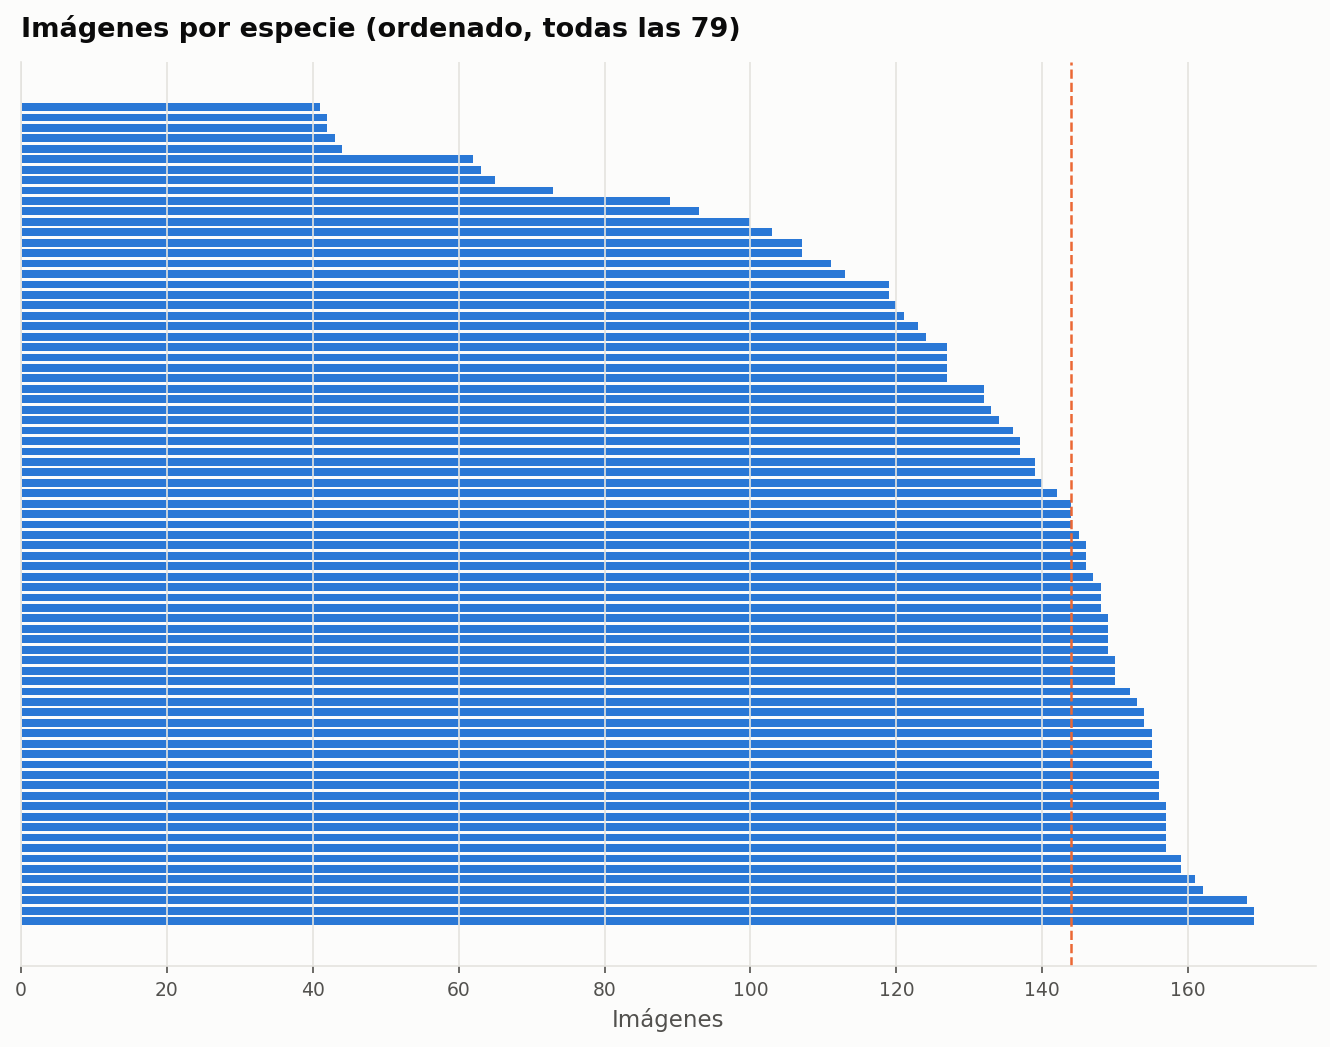

In [5]:
applyStyle()
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, max(4, 0.09 * len(conteos))))
ax.barh(range(len(conteos)), conteos["total"], color=SERIE_1, height=0.75)
ax.set_yticks([])
ax.set(xlabel="Imágenes", title="Imágenes por especie (ordenado, todas las 79)")
ax.axvline(conteos["total"].median(), color=SERIE_2, linestyle="--", linewidth=1.2)
fig.tight_layout()
plt.show()

In [6]:
print("Especie con más imágenes:")
print(conteos.iloc[0][["especie", "total"]].to_string())
print("\nEspecie con menos imágenes:")
print(conteos.iloc[-1][["especie", "total"]].to_string())

Especie con más imágenes:
especie    adelpha_alala
total                169

Especie con menos imágenes:
especie    taygetis_sylvia
total                   41


## 3 · Especies de cola larga (< 40 imágenes)

In [7]:
colaLarga = conteos[conteos["total"] < 40].sort_values("total")
print(f"{len(colaLarga)} especies por debajo de 40 imágenes")
colaLarga[["especie", "train", "test", "validate", "total"]]

0 especies por debajo de 40 imágenes


,especie,train,test,validate,total


## 4 · Proporción del split por especie

El split es 70/20/10 combinando semilla + nombre de especie; se verifica que
se cumpla razonablemente incluso en las especies más escasas.

In [8]:
proporciones = conteos.copy()
for s in ("train", "test", "validate"):
    proporciones[f"{s}_pct"] = proporciones[s] / proporciones["total"]
proporciones[["especie", "total", "train_pct", "test_pct", "validate_pct"]].describe()

,total,train_pct,test_pct,validate_pct
count,79.000000,79.000000,79.000000,79.000000
mean,130.607595,0.699499,0.199817,0.100685
std,33.284484,0.002740,0.003097,0.004584
min,41.000000,0.690476,0.190476,0.090909
25%,120.500000,0.697987,0.197452,0.097482
50%,144.000000,0.699248,0.200000,0.100671
75%,154.000000,0.700861,0.201439,0.102564
max,169.000000,0.707692,0.209302,0.119048


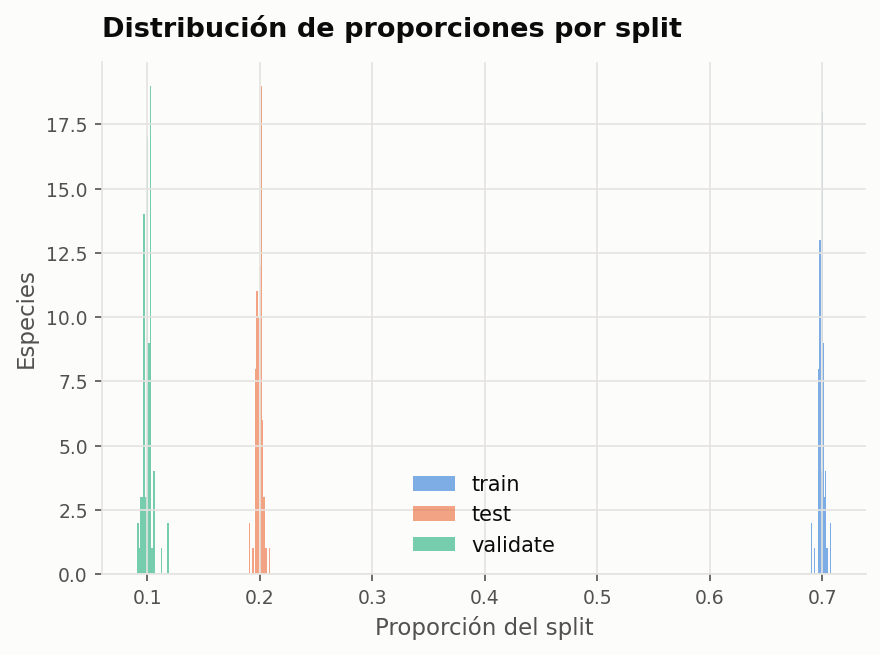

In [9]:
applyStyle()
fig, ax = plt.subplots(figsize=(6, 4.5))
for col, color, label in (
    ("train_pct", SERIE_1, "train"),
    ("test_pct", SERIE_2, "test"),
    ("validate_pct", SERIE_3, "validate"),
):
    ax.hist(proporciones[col], bins=20, color=color, alpha=0.6, label=label)
ax.set(xlabel="Proporción del split", ylabel="Especies", title="Distribución de proporciones por split")
ax.legend()
fig.tight_layout()
plt.show()

## 5 · Ejemplos por especie

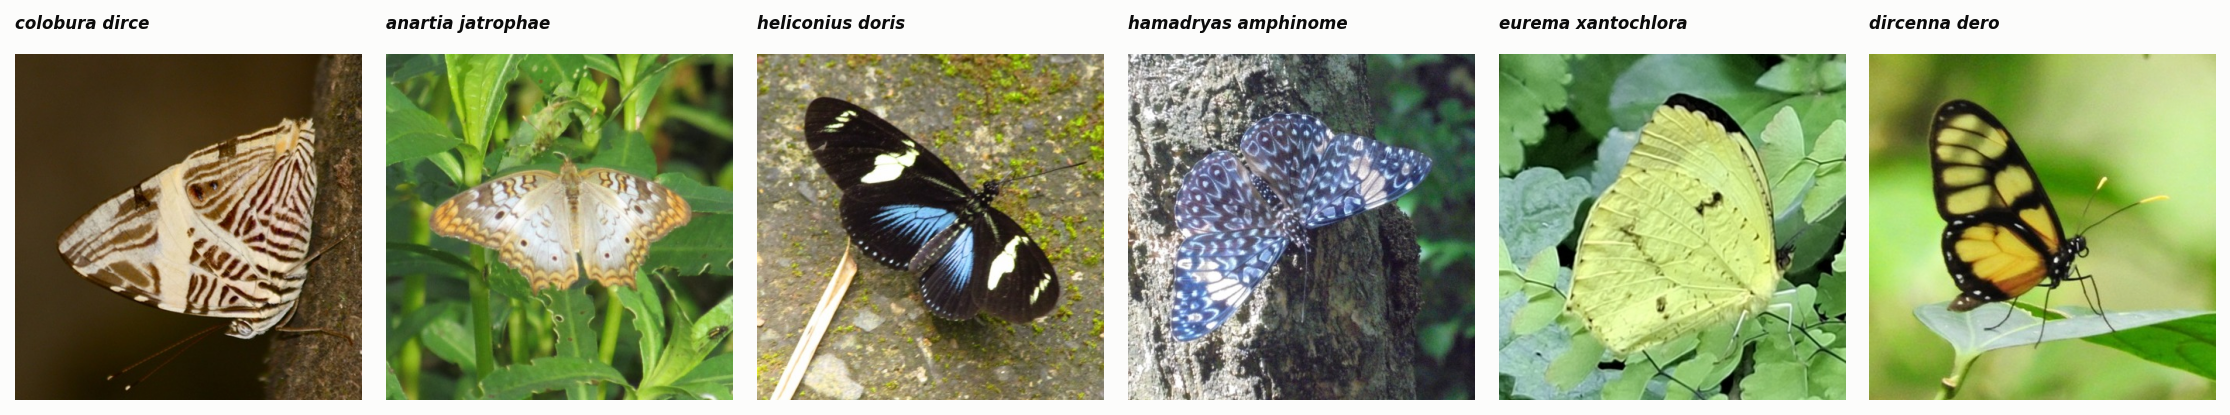

In [10]:
import random

from PIL import Image

random.seed(42)
muestraEspecies = random.sample(sorted(reparto.keys()), 6)

applyStyle()
fig, ejes = plt.subplots(1, len(muestraEspecies), figsize=(15, 3))
for ax, especie in zip(ejes, muestraEspecies):
    archivo = reparto[especie]["train"][0]
    img = Image.open(Path("dataset/train") / especie / archivo)
    ax.imshow(img)
    limpiarEje(ax)
    ax.set_title(especie.replace("_", " "), fontsize=8, style="italic")
fig.tight_layout()
plt.show()

## 6 · Tamaño de imagen

In [11]:
tamanos = set()
for especie in muestraEspecies:
    for archivo in reparto[especie]["train"][:5]:
        img = Image.open(Path("dataset/train") / especie / archivo)
        tamanos.add(img.size)
print("Tamaños encontrados en la muestra:", tamanos)

Tamaños encontrados en la muestra: {(448, 448)}


## Resumen

- 79 clases usables, split 70/20/10 ya armado por `ButterflyDataset` (semilla 42).
- Imágenes preprocesadas a 448×448 RGB — el pipeline de entrenamiento las
  reescala a 320×320
- El corpus está desbalanceado (ver especies de cola larga); todos los
  entrenamientos usan `class_weight="balanced"` para compensarlo.